In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
TCS= yf.download ("TCS.NS",start='2023-01-01',end='2025-01-01',interval="1d")
TCS.columns= TCS.columns.droplevel(1)
TCS=TCS.reset_index()
price = TCS['Close'].dropna()
TCS

/tmp/ipython-input-3975895478.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  TCS= yf.download ("TCS.NS",start='2023-01-01',end='2025-01-01',interval="1d")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2023-01-02,3121.404297,3126.572563,3096.281464,3120.973666,709547
1,2023-01-03,3169.162598,3177.441078,3105.948701,3112.360960,1245178
2,2023-01-04,3172.320068,3184.474922,3145.091748,3164.711485,1231668
3,2023-01-05,3168.922852,3193.997788,3141.024400,3187.202565,1826057
4,2023-01-06,3073.647461,3159.782899,3062.593366,3158.299409,2488376
...,...,...,...,...,...,...
486,2024-12-24,4118.851074,4156.792399,4097.958516,4097.958516,1181886
487,2024-12-26,4108.602539,4139.004973,4083.028905,4118.851529,1208464
488,2024-12-27,4104.414551,4120.281022,4087.069846,4102.591300,858100
489,2024-12-30,4098.451172,4138.363474,4052.330482,4090.764551,1527169


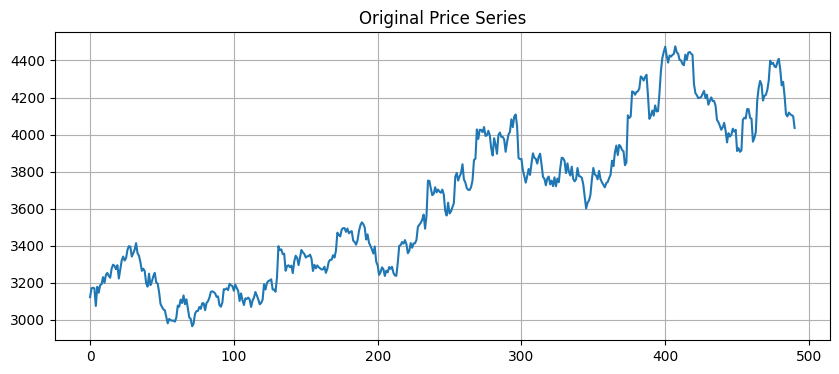

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(price)
plt.title("Original Price Series")
plt.grid(True)
plt.show()


In [4]:
diff1 = price.diff().dropna()

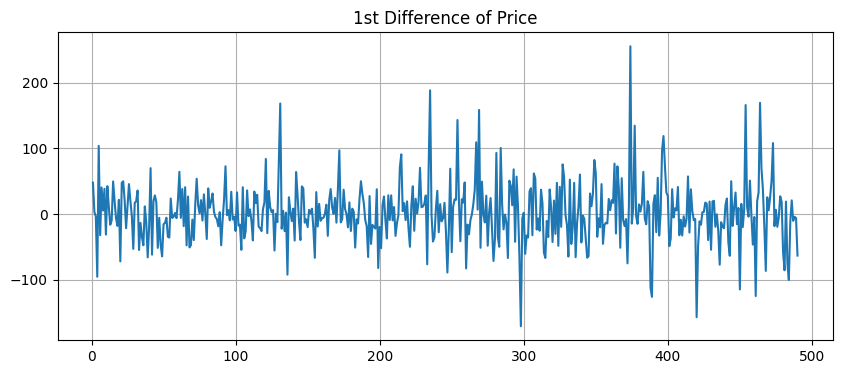

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(diff1, label="1st Difference")
plt.title("1st Difference of Price")
plt.grid(True)
plt.show()

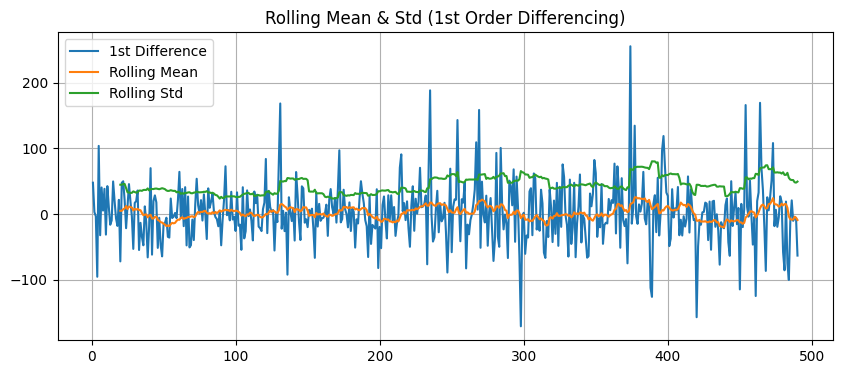

In [6]:
rolling_mean = diff1.rolling(window=20).mean()
rolling_std = diff1.rolling(window=20).std()

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(diff1, label='1st Difference')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title("Rolling Mean & Std (1st Order Differencing)")
plt.grid(True)
plt.show()

In [7]:
split = int(0.8 * len(diff1))
train = diff1[:split]
test = diff1[split:]


In [8]:
i = 1
results = []

while i <= 10:
    try:
        model = ARIMA(train, order=(i, 0, i))
        fitted = model.fit()
        forecast = fitted.forecast(steps=len(test))
        mse = mean_squared_error(test, forecast)
        results.append((i, mse))
        print(f"ARMA({i},{i}) MSE: {mse:.6f}")
    except Exception as e:
        print(f"ARMA({i},{i}) failed: {e}")
        results.append((i, np.inf))
    i += 1

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

ARMA(1,1) MSE: 2633.889266


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq

ARMA(2,2) MSE: 2626.363306


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the

...

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq

ARMA(8,8) MSE: 2659.072834


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq

ARMA(9,9) MSE: 2630.306975
ARMA(10,10) MSE: 2668.628622


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [9]:
best_i, best_mse = min(results, key=lambda x: x[1])
print(f"\nBest model: ARMA({best_i},{best_i}) with MSE = {best_mse:.2f}")



Best model: ARMA(7,7) with MSE = 2616.69


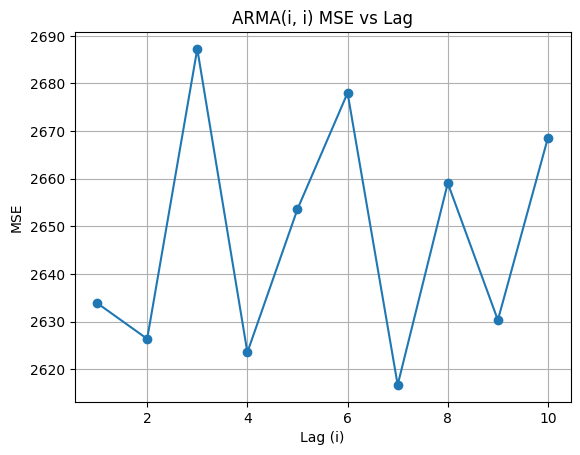

In [10]:
lags = []
errors = []
for lag, error in results:
    lags.append(lag)
    errors.append(error)

plt.plot(lags, errors, marker='o')
plt.xlabel("Lag (i)")
plt.ylabel("MSE")
plt.title("ARMA(i, i) MSE vs Lag")
plt.grid(True)
plt.show()
